## CMPINF 2100 Final Project

### Models: Performance and Validation (25 points)

*Note: Part D focused on fitting models on the training set and studying the coefficients. Performance was assessed ONLY on the training set. Part F is focused on identifying the model that will perform the best on NEW data. You will use CROSS-VALIDATION to calculate a more reliable estimate of the model performance.*

* You will use 3 of the formulations you considered in Part D.
  * You must select the formulation that was the best model on the training set.
  * You must choose 2 additional formulations. One should be simple (few features), and one should be of medium to high complexity.
* You must use CROSS-VALIDATION to evaluate the performance for each of the 3 models. Using “regular” K-fold OR stratified K-fold depends on whether you are working on a REGRESSION or CLASSIFICATION problem. You may choose 5-fold, 10-fold, or repeated cross-validation. You must identify an appropriate performance metric to focus on based on the output data type.
* Visualize the CROSS-VALIDATION results by showing the AVERAGE CROSS-VALIDATION performance metric with the 95% confidence interval for each model.
* Which model is the BEST according to CROSS-VALIDATION?
* Is this model DIFFERENT from the model identified as the BEST according to the training set?
* How many regression coefficients are associated with the best model?
* Important considerations
  * PRE-PROCESSING actions like standardization must be applied within each FOLD and CANNOT be performed BEFORE applying CROSS-VALIDATION (discussed in Weeks 13-14).
  * PRE-PROCESSING actions like applying LOG-TRANSFORMATIONS can be performed BEFORE applying CROSS-VALIDATION.
  * There are multiple ways to approach executing the CROSS-VALIDATION. Select the approach you feel is best for you.
  * You may use scikit-learn to manage the data splitting required for CROSS-VALIDATION.
  * You may fit the models with statsmodels OR scikit-learn based functions.
  * You may use the Pipeline module to manage all aspects of preprocessing, model fitting, evaluating, and running cross-validation.
  * Include discussion text in your main report associated with applying CROSS-VALIDATION to identify the best model.
  * Your supporting notebook can be used for practice. This lets you practice the CROSS-VALIDATION away from the rest of the work for the project. This approach is recommended to make your work more modular.

## Import Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
import statsmodels.formula.api as smf

## Read Data

In [3]:
dfa = pd.read_csv('spotify_data_standard_clean.csv')

In [4]:
## modify release_month, playlist_genre, key, bin_year, and mode to categoricals

dfa['release_month'] = dfa.release_month.astype('category')
dfa['playlist_genre'] = dfa.playlist_genre.astype('category')
dfa['mode'] = dfa['mode'].astype('category')
dfa['key'] = dfa.key.astype('category')
dfa['bin_year'] = dfa.bin_year.astype('category')

## change the name of the mode column to make my life easier
dfa.rename(columns={'mode':'Mode'}, inplace=True)
dfa['Mode'] = dfa.Mode.astype('str')

dfa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   danceability      28356 non-null  float64 
 1   energy            28356 non-null  float64 
 2   loudness          28356 non-null  float64 
 3   speechiness       28356 non-null  float64 
 4   acousticness      28356 non-null  float64 
 5   instrumentalness  28356 non-null  float64 
 6   liveness          28356 non-null  float64 
 7   valence           28356 non-null  float64 
 8   tempo             28356 non-null  float64 
 9   duration_ms       28356 non-null  float64 
 10  playlist_genre    28356 non-null  category
 11  key               28356 non-null  category
 12  Mode              28356 non-null  object  
 13  release_month     28356 non-null  category
 14  binary_outcome    28356 non-null  int64   
 15  bin_year          28356 non-null  category
dtypes: category(4), float6

### Model Selection

* You will use 3 of the formulations you considered in Part D.
  * You must select the formulation that was the best model on the training set.
  * You must choose 2 additional formulations. One should be simple (few features), and one should be of medium to high complexity.

In [5]:
formula_best_train = 'binary_outcome ~ (bin_year + playlist_genre + key + Mode + release_month) * ((danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms)**2) + np.power(danceability, 2) + np.power(energy, 2) + np.power(loudness, 2) + np.power(speechiness, 2) + np.power(acousticness, 2) + np.power(instrumentalness, 2) + np.power(liveness, 2) + np.power(valence, 2) + np.power(tempo, 2) + np.power(duration_ms, 2)'
formula_simple = 'binary_outcome ~ danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms'
formula_complex = 'binary_outcome ~ (bin_year + playlist_genre + key + Mode + release_month) * (np.power(danceability, 2) + np.power(energy, 2) + np.power(loudness, 2) + np.power(speechiness, 2) + np.power(acousticness, 2) + np.power(instrumentalness, 2) + np.power(liveness, 2) + np.power(valence, 2) + np.power(tempo, 2) + np.power(duration_ms, 2))'

In [6]:
formula_list = [formula_best_train, formula_complex, formula_simple]

### Cross-Validation

You must use CROSS-VALIDATION to evaluate the performance for each of the 3 models. Using “regular” K-fold OR stratified K-fold depends on whether you are working on a REGRESSION or CLASSIFICATION problem. You may choose 5-fold, 10-fold, or repeated cross-validation. You must identify an appropriate performance metric to focus on based on the output data type.

In [7]:
## import StratifiedKFold for the classification problem

from sklearn.model_selection import StratifiedKFold

In [8]:
## intialize 5-fold cv

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2100)

In [9]:
## import other helpers

from sklearn.linear_model import LogisticRegression
from patsy import dmatrices
from sklearn.model_selection import cross_val_score

In [10]:
## initialize the model

sk_min_loss = LogisticRegression(penalty=None, solver='lbfgs', fit_intercept=False, max_iter=25001)

In [11]:
## formula copied from 'week_13_cv_sklearn_cross_val_score'

def logistic_cross_val_score(mod_name, a_formula, init_mod, data_df, cv):
    # create the feature and outuput arrays using the formula
    y, X = dmatrices( a_formula, data = data_df)

    # train and test within each fold - return test scores
    test_res = cross_val_score( init_mod, X, y.ravel(), cv=cv )

    # book keeping
    res_df = pd.DataFrame({'Accuracy':test_res})
    res_df['fold_id'] = res_df.index + 1
    res_df['model_name'] = mod_name
    res_df['mdodel_formula'] = a_formula
    res_df['num_coefs'] = X.shape[1]

    return res_df

In [12]:
## test on one formula

logistic_cross_val_score(2, formula_list[2], sk_min_loss, data_df=dfa, cv=kf)

,Accuracy,fold_id,model_name,mdodel_formula,num_coefs
0,0.589034,1,2,binary_outcome ~ danceability + energy + loudn...,11
1,0.583848,2,2,binary_outcome ~ danceability + energy + loudn...,11
2,0.587727,3,2,binary_outcome ~ danceability + energy + loudn...,11
3,0.593722,4,2,binary_outcome ~ danceability + energy + loudn...,11
4,0.580497,5,2,binary_outcome ~ danceability + energy + loudn...,11


In [13]:
# Iterate over all models and store results

cv_score_list = []

for m in range(len(formula_list)):
    cv_score_list.append( logistic_cross_val_score( m, formula_list[m], init_mod=sk_min_loss, data_df=dfa, cv=kf))

cv_score_df = pd.concat(cv_score_list, ignore_index=True)

cv_score_df

,Accuracy,fold_id,model_name,mdodel_formula,num_coefs
0,0.614245,1,0,binary_outcome ~ (bin_year + playlist_genre + ...,1690
1,0.605537,2,0,binary_outcome ~ (bin_year + playlist_genre + ...,1690
2,0.606948,3,0,binary_outcome ~ (bin_year + playlist_genre + ...,1690
3,0.599718,4,0,binary_outcome ~ (bin_year + playlist_genre + ...,1690
4,0.603245,5,0,binary_outcome ~ (bin_year + playlist_genre + ...,1690
5,0.620063,1,1,binary_outcome ~ (bin_year + playlist_genre + ...,330
6,0.597602,2,1,binary_outcome ~ (bin_year + playlist_genre + ...,330
7,0.606242,3,1,binary_outcome ~ (bin_year + playlist_genre + ...,330
8,0.605184,4,1,binary_outcome ~ (bin_year + playlist_genre + ...,330
9,0.595662,5,1,binary_outcome ~ (bin_year + playlist_genre + ...,330


**Visualize the CROSS-VALIDATION results by showing the AVERAGE CROSS-VALIDATION performance metric with the 95% confidence interval for each model.**

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


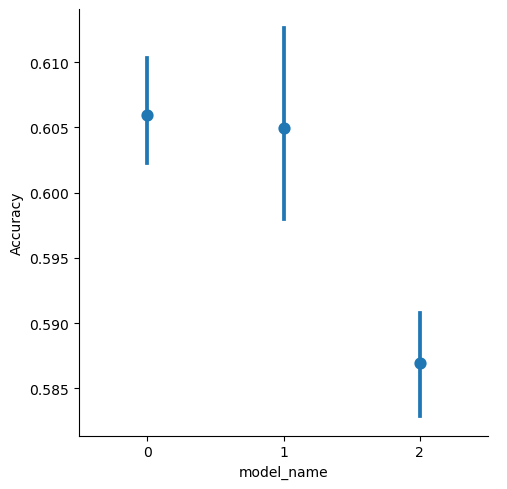

In [14]:
sns.catplot(data=cv_score_df, x='model_name', y='Accuracy',
           kind='point', linestyle='none', errorbar=('ci', 95))

plt.show()

**Which model is the BEST according to CROSS-VALIDATION?**

Models 0 and 1 have the best performance, with Model 0 having a slightly better average performance.

**Is this model DIFFERENT from the model identified as the BEST according to the training set?**

No, this is the same model that was identified as the best according to the training set.

**How many regression coefficients are associated with the best model?**

There are 1690 regression coefficients associated with model 0.

In [17]:
formula_list[0]

'binary_outcome ~ (bin_year + playlist_genre + key + Mode + release_month) * ((danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms)**2) + np.power(danceability, 2) + np.power(energy, 2) + np.power(loudness, 2) + np.power(speechiness, 2) + np.power(acousticness, 2) + np.power(instrumentalness, 2) + np.power(liveness, 2) + np.power(valence, 2) + np.power(tempo, 2) + np.power(duration_ms, 2)'